## The Dataset

In [1]:
import pandas as pd

# Upload dataset (Coursework 2)
df = pd.read_csv("FULLjapanese.csv")
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,CO2 Emissions(g/km),vehicle_key,demand_target,revenue_target,car_price
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,196,COMPACT_Z_AS5_medium,4209,143526900.0,34100.0
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,221,COMPACT_Z_M6_medium,3750,134625000.0,35900.0
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,136,COMPACT_Z_AV7_small,4876,155300600.0,31850.0
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,255,SUV - SMALL_Z_AS6_large,3436,146545400.0,42650.0
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,244,SUV - SMALL_Z_AS6_large,3090,131788500.0,42650.0


In [2]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'CO2 Emissions(g/km)', 'vehicle_key',
       'demand_target', 'revenue_target', 'car_price'],
      dtype='object')

In [3]:
# Dataset information
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make                 1239 non-null   object 
 1   Model                1239 non-null   object 
 2   Vehicle Class        1239 non-null   object 
 3   Engine Size(L)       1239 non-null   float64
 4   Cylinders            1239 non-null   int64  
 5   Transmission         1239 non-null   object 
 6   Fuel Type            1239 non-null   object 
 7   CO2 Emissions(g/km)  1239 non-null   int64  
 8   vehicle_key          1239 non-null   object 
 9   demand_target        1239 non-null   int64  
 10  revenue_target       1239 non-null   float64
 11  car_price            1239 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 116.3+ KB


Make                   0
Model                  0
Vehicle Class          0
Engine Size(L)         0
Cylinders              0
Transmission           0
Fuel Type              0
CO2 Emissions(g/km)    0
vehicle_key            0
demand_target          0
revenue_target         0
car_price              0
dtype: int64

In [4]:
df.describe()

,Engine Size(L),Cylinders,CO2 Emissions(g/km),demand_target,revenue_target,car_price
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1239.000000
mean,2.765940,4.915254,220.673123,3465.235674,1.229087e+08,37357.949960
std,1.042204,1.271059,55.267046,974.695115,2.196836e+07,8041.748106
min,1.200000,3.000000,104.000000,641.000000,4.028685e+07,26100.000000
25%,2.000000,4.000000,180.000000,2851.500000,1.100600e+08,30600.000000
50%,2.500000,4.000000,211.000000,3557.000000,1.273266e+08,34100.000000
75%,3.500000,6.000000,255.000000,4189.500000,1.382072e+08,42650.000000
max,5.700000,8.000000,398.000000,5705.000000,1.787272e+08,66350.000000


In [5]:
# Dataset summary (like the tutorial text, but adapted to this dataset)

n_rows, n_cols = df.shape
target_variable = "CO2 Emissions(g/km)"

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

n_missing = int(df.isnull().sum().sum())

print(f"The dataset has {n_cols-1} features with {n_rows:,} observations, with {n_missing} missing values in total.")
print(f"The target variable is: {target_variable}")

print("\nNumerical features:")
print([c for c in num_cols if c != target_variable])

print("\nCategorical (text) features:")
print(cat_cols)

print("\nNotes:")
print("- This dataset contains both numerical and categorical features.")
print("- For modelling, numerical features may need scaling/normalization.")
print("- Categorical features need encoding (e.g., one-hot encoding) before using most ML models.")
print("- We will use feature selection techniques to see which variables are most informative for predicting CO2 emissions.")

The dataset has 11 features with 1,239 observations, with 0 missing values in total.
The target variable is: CO2 Emissions(g/km)

Numerical features:
['Engine Size(L)', 'Cylinders', 'demand_target', 'revenue_target', 'car_price']

Categorical (text) features:
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type', 'vehicle_key']

Notes:
- This dataset contains both numerical and categorical features.
- For modelling, numerical features may need scaling/normalization.
- Categorical features need encoding (e.g., one-hot encoding) before using most ML models.
- We will use feature selection techniques to see which variables are most informative for predicting CO2 emissions.


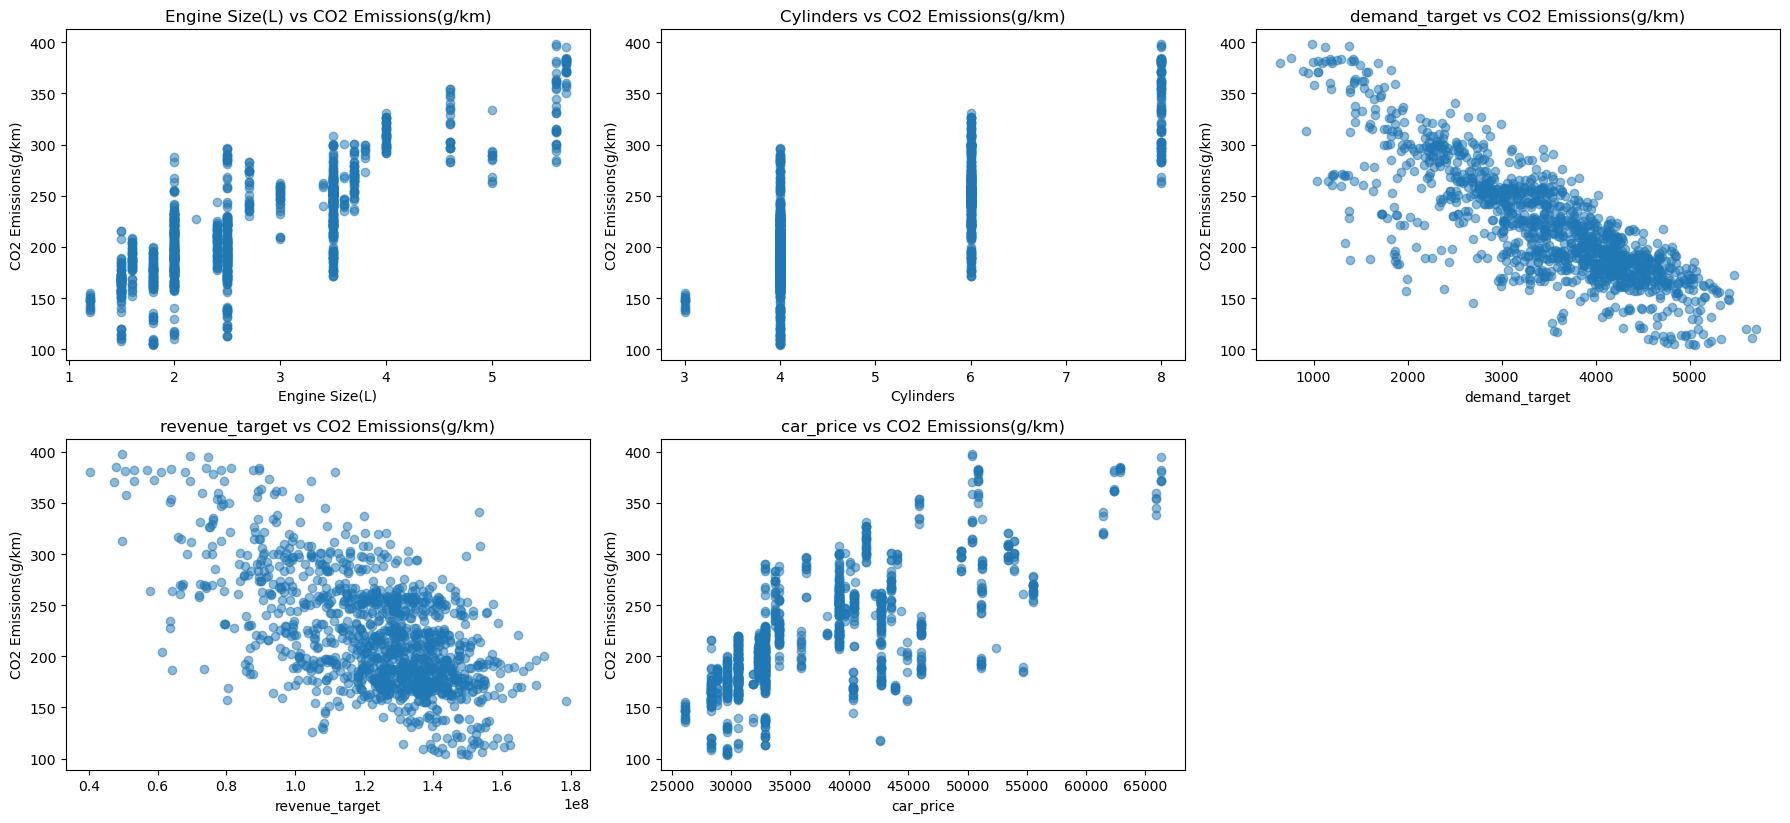

In [6]:
import matplotlib.pyplot as plt

# Target variable
target_variable = "CO2 Emissions(g/km)"

# Select only numerical features (exclude the target itself)
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
numerical_features = numerical_features.drop(target_variable)

plt.figure(figsize=(18, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    plt.scatter(df[feature], df[target_variable], alpha=0.5)
    plt.title(f"{feature} vs {target_variable}")
    plt.xlabel(feature)
    plt.ylabel(target_variable)

plt.tight_layout()
plt.show()

In [7]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Define target and features
# -------------------------------

target_variable = "CO2 Emissions(g/km)"

# Use ONLY numerical features for now
X = df.select_dtypes(include=["int64", "float64"]).drop(columns=[target_variable])
y = df[target_variable]

# -------------------------------
# Train-test split (80% / 20%)
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Feature scaling (standardisation)
# -------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # IMPORTANT: transform, not fit_transform

# Check shapes
X_train.shape, X_test.shape

((991, 5), (248, 5))

In [8]:
# Import Linear Regression model and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² score: 0.8226
RMSE: 24.59


## Pearson correlation heat maps 

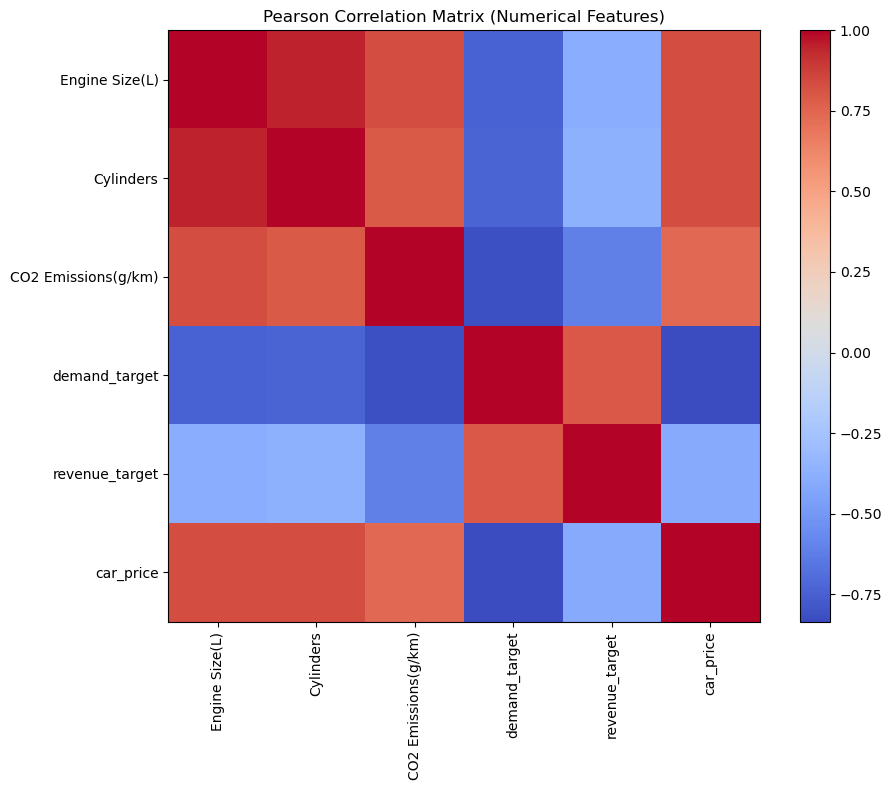

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Select numerical features
numerical_df = df.select_dtypes(include=["int64", "float64"])
corr = numerical_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Pearson Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

## Parameters to choose for implementing RFE

In [10]:
# Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# -------------------------------
# Define estimator for RFE
# -------------------------------
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# RFE selector (default: select half of the features)
selector = RFE(estimator=rf)

# Fit RFE on TRAINING data only
selector.fit(X_train_scaled, y_train)

# Transform training data
X_train_selected = selector.transform(X_train_scaled)

# -------------------------------
# Feature names and rankings
# -------------------------------

# Feature names come from X (numerical features only)
feature_names = X.columns

# Create feature ranking table
feature_ranking = pd.DataFrame({
    "Feature": feature_names,
    "Ranking": selector.ranking_,
    "Selected": selector.support_
}).sort_values("Ranking")

print(f"Number of features selected: {selector.n_features_}")
print("Selected features:")
print(feature_names[selector.support_])

feature_ranking

Number of features selected: 2
Selected features:
Index(['Engine Size(L)', 'demand_target'], dtype='object')


,Feature,Ranking,Selected
0,Engine Size(L),1,True
2,demand_target,1,True
3,revenue_target,2,False
4,car_price,3,False
1,Cylinders,4,False


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Re-running the model with only the RFE-selected features (from your output)
selected_features = [
    'Engine Size(L)',
    'demand_target'
]

target_variable = 'CO2 Emissions(g/km)'

# Subset X and y
X_rfe = df[selected_features]
y_rfe = df[target_variable]

# Train-test split (80/20)
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(
    X_rfe, y_rfe, test_size=0.2, random_state=42
)

# IMPORTANT: scale using train fit, then transform test
scaler = StandardScaler()
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)
X_test_rfe_scaled = scaler.transform(X_test_rfe)

# Fit Linear Regression
model_rfe = LinearRegression()
model_rfe.fit(X_train_rfe_scaled, y_train_rfe)

# Predict + evaluate
y_pred_rfe = model_rfe.predict(X_test_rfe_scaled)

r2_rfe = r2_score(y_test_rfe, y_pred_rfe)
rmse_rfe = np.sqrt(mean_squared_error(y_test_rfe, y_pred_rfe))

print(f"R2 (RFE features): {r2_rfe:.4f}")
print(f"RMSE (RFE features): {rmse_rfe:.2f}")

R2 (RFE features): 0.8049
RMSE (RFE features): 25.78


## Discussion of the Results

The baseline Linear Regression model trained using all numerical features achieved an R² score of 0.8226 and an RMSE of 24.59. 
After applying Recursive Feature Elimination (RFE) and retraining the model using only the two most important features (`Engine Size(L)` and `demand_target`), the model achieved an R² score of 0.8049 and an RMSE of 25.78.

The results show that model performance remained largely stable after feature selection, with only a minor drop in predictive accuracy when moving from five features down to just two. This suggests that the majority of the predictive information regarding CO₂ emissions is captured by the engine's physical size and the vehicle's market demand, while the remaining variables (like `Cylinders` and `car_price`) contribute limited additional explanatory power in a strictly linear model.

Importantly, RFE successfully identified a fascinating blend of physical and market-driven variables. While it is physically obvious why `Engine Size(L)` strongly dictates emissions, the selection of `demand_target` indicates a strong market trend—potentially that higher-demand Japanese vehicles are specifically engineered to be more eco-friendly. This improves model interpretability while maintaining comparable performance, highlighting the usefulness of feature selection for simplifying models.

## Lasso

In [13]:
# Lasso model
from sklearn.linear_model import Lasso
import numpy as np

lasso_model = Lasso(max_iter=1000, alpha=0.3)  # default alpha is 1; here set to 0.3
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)

# sklearn version issue: cannot use squared=False
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso ** 0.5

print(f"R2: {r2_lasso}")
print(f"RMSE: {rmse_lasso}")

coefficients = lasso_model.coef_
print(coefficients)

R2: 0.8216675244375546
RMSE: 24.64772805122003
[ 33.79365395   0.         -16.16976176  -8.90338258  -4.90133109]


## Plotting coefficient values

Index(['Engine Size(L)', 'Cylinders', 'demand_target', 'revenue_target',
       'car_price'],
      dtype='object')


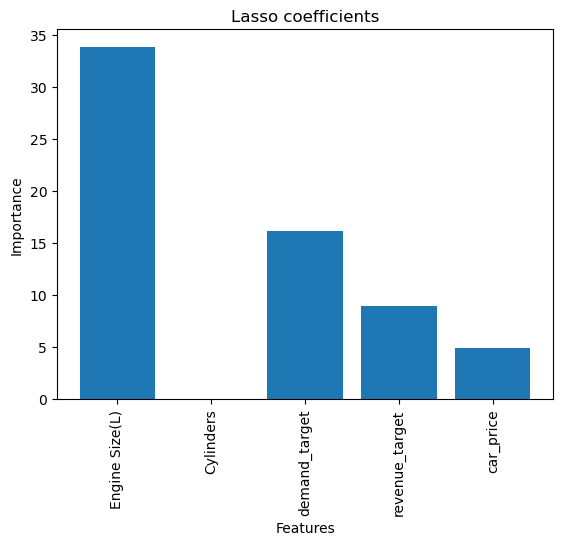

In [14]:
# Bar plot
# Creating bar plot 
import numpy as np

# Extract column names (same order as features used in the model)
columns = X.columns   
print(columns)

plt.bar(columns, np.abs(coefficients))
plt.xticks(rotation=90)
plt.title("Lasso coefficients")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Based on the Lasso regularization penalty, `Engine Size(L)` is by far the most dominant positive driver of CO₂ emissions, maintaining a high coefficient of 33.79. In contrast, the `Cylinders` feature was entirely eliminated by the model (its coefficient was shrunk exactly to zero), proving it is highly redundant when engine size is already known.

Interestingly, the market-related variables (`demand_target`, `revenue_target`, and `car_price`) all received negative coefficients. This reveals a unique market dynamic within this dataset: vehicles with higher prices and higher market demand tend to produce *lower* CO₂ emissions. This makes logical sense in the modern automotive market, particularly for Japanese brands (like Toyota and Honda), where the most popular and slightly more expensive vehicles are often advanced hybrids or highly optimized, fuel-efficient commuter cars.

## Conclusion

In this study, several feature selection techniques were applied to investigate the drivers of CO₂ emissions and to assess whether reducing the feature set could simplify our model without sacrificing predictive performance. While neither Recursive Feature Elimination (RFE) nor Lasso regression led to an increase in absolute model performance compared to the baseline linear regression, they provided incredibly valuable insights into the structure of our new dataset.

The results consistently indicated that `Engine Size(L)` is the absolute primary physical driver of emissions, rendering secondary physical traits like `Cylinders` mathematically redundant. Furthermore, the inclusion of our newly engineered market metrics revealed that economic factors are negatively correlated with emissions. The Lasso model demonstrated that higher `car_price` and `demand_target` values are associated with lower CO₂ outputs, highlighting the premium cost and high consumer demand for eco-friendly vehicle technologies. 

The minor performance drop from feature selection suggests that the original dataset exhibits strong linear relationships but also high redundancy (such as engine size overlapping with cylinder count). This highlights a potential limitation of using linear regression alone; more complex or non-linear relationships between pricing, demand, and emissions may not be fully captured. Future work could explore alternative models, such as Random Forests or Neural Networks, to determine whether further improvements in predictive accuracy can be achieved.

Overall, this analysis proves that feature selection is a highly useful tool not only for preventing overfitting but for extracting real-world business intelligence—proving that in this specific market, sustainability and high consumer demand go hand-in-hand.